In [26]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


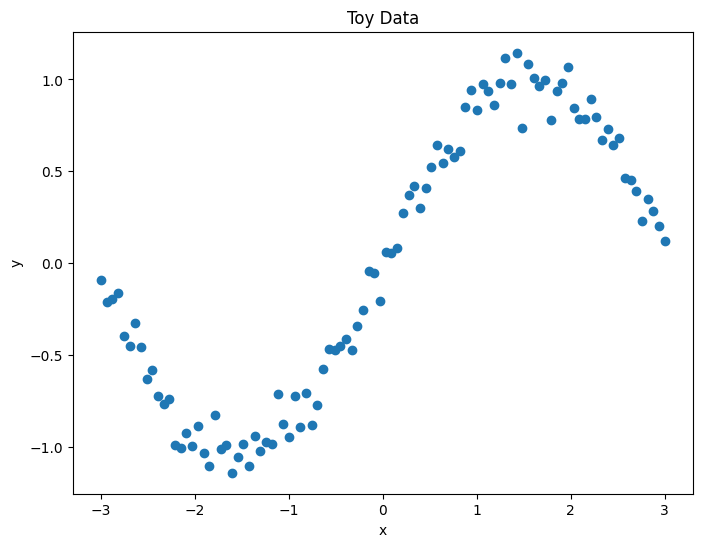

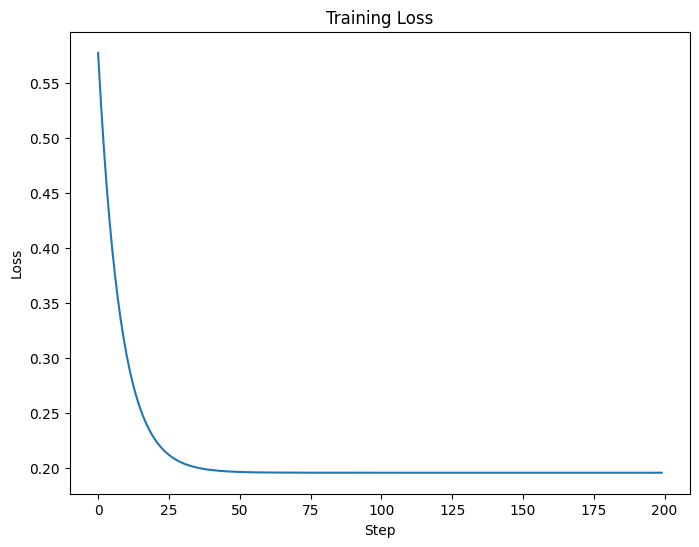

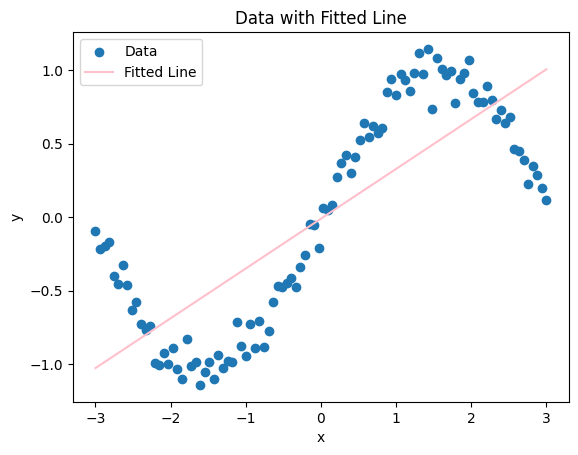

In [27]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100); y = np.sin(x) + np.random.randn(100) * 0.1

#   Plot it.
plt.figure(figsize=(8, 6))
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data')
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
losses = []
lr = 0.01
for step in range(200):
    y_hat = w * x + b

    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    #   Record the loss at every step.
    losses.append(loss)
# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
#           (b) the data with the fitted line on top.
plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x, w * x + b, color='pink', label='Fitted Line')
plt.title('Data with Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

**Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![Derivative](image.jpeg)

**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The loss stops improving even though the predictions remain poor because a single neuron can only produce a linear (straight-line) function. The data, however, come from y = sin(x) + noise, which is fundamentally nonlinear. Gradient descent can only tune the two parameters w and b; it cannot alter the model’s functional form from a line into a curve. After enough iterations it simply converges to the best possible straight-line fit, and the loss plateaus. Capturing the true relationship therefore requires a model that can represent nonlinear mappings—for example a neural network with one or more hidden layers and nonlinear activation functions. The observed failure is classic underfitting: the model is too simple to express the pattern present in the data.

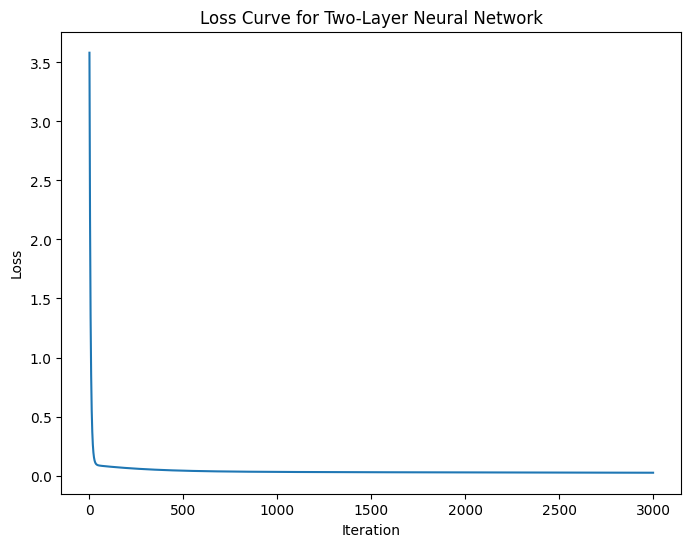

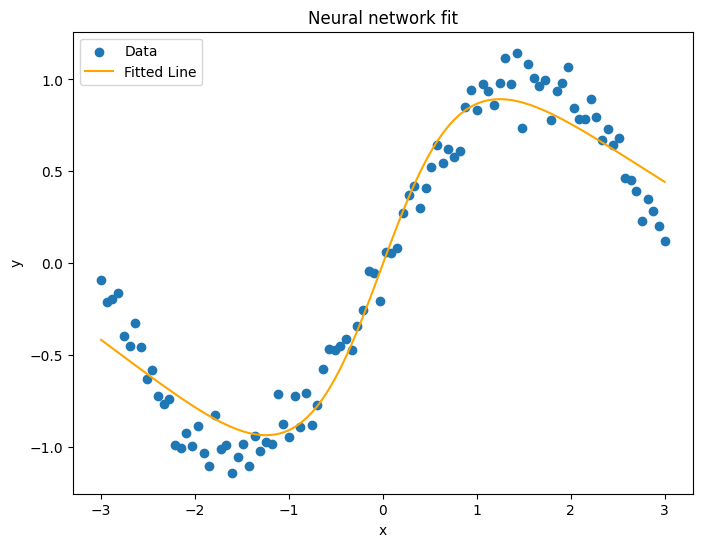

In [28]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
w1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

w2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1, 1) 
y = y.reshape(-1, 1)
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ w1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ w2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ w2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
db1= dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
w1 -= lr * dW1
b1 -= lr * db1
w2 -= lr * dW2
b2 -= lr * db2

losses = []

for i in range(3000):
    z1 = x @ w1 + b1
    h  = np.tanh(z1)
    y_hat = h @ w2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    w1 -= lr * dW1
    b1 -= lr * db1
    w2 -= lr * dW2
    b2 -= lr * db2
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curve for Two-Layer Neural Network')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data')
plt.plot(x, y_hat, color='orange', label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Neural network fit')
plt.legend()
plt.show()


**Student Reasoning — Depth and activations**
**1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.**
Without activation functions the network is simply
z1=xW1+b1, y= ̂z1 W2+b2.

Substituting the first equation into the second gives
y ̂=(xW_1+b_1 ) W_2+b_2=x(W_1 W_2 )+(b_1 W_2+b_2 ),

which is just the single affine map y ̂=xW+bfor the effective weights W=W_1 W_2and bias b=b_1 W_2+b_2. The same reduction holds for any number of successive linear layers, so the whole stack remains a linear function. Depth alone therefore cannot increase the model’s ability to capture complex patterns; the non-linearity introduced by an activation function is what enables the network to represent non-linear relationships.


**2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)**
The eight hidden neurons function as feature extractors. Each neuron takes the input (x), applies its own set of weights and a bias, and generates a unique nonlinear output. Since the activation function is nonli
near, every neuron learns a distinct curved representation of the input. These eight learned representations are then combined by the output neuron to produce an approximation of the sine wave.

**3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?**
Backpropagation is the process of computing the gradients of the loss function with respect to each network parameter and propagating the error backward through the network so the weights and biases can be updated to reduce the loss.
